<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 700px;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h1 style="font-size: 48px; margin-bottom: 20px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Jose Carlos Fernandez</strong><h1>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Fecha:</strong> 8 de agoso de 2025</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Maestro:</strong> Esloboan Alberto Mora</p>
    <h1 style="font-size: 22px; margin-bottom: 10px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Instituto Tecnológico de Las Américas</strong><h1>

</div>


<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 40%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Analisis de Sensibilidad</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Ejercicio 2, en Python.
    </p>
</div>

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Problema de Mezclas Químicas**

> **Planteamiento del Problema:**

Hola! En este cuaderno voy a resolver un problema de optimización relacionado con la producción de mezclas químicas. Tenemos lo siguiente:

Una planta produce tres tipos de mezclas químicas X, Y y Z con ganancias por tonelada de $60, $70 y $100 respectivamente. 

> **Los recursos disponibles semanalmente son:**

- Reactivo A: 300 unidades
- Reactivo B: 500 unidades
- Reactivo C: 200 unidades

> **Cada mezcla requiere diferentes cantidades de reactivos:**

- Mezcla X: 20 unidades de A, 10 de B, 5 de C
- Mezcla Y: 10 unidades de A, 20 de B, 10 de C
- Mezcla Z: 10 unidades de A, 10 de B, 20 de C

> **Mi objetivo es maximizar la ganancia total.**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Formulación del Modelo Matemático**

Primero voy a definir mis variables de decisión:

- x = Toneladas de mezcla X a producir
- y = Toneladas de mezcla Y a producir
- z = Toneladas de mezcla Z a producir

> **La función objetivo (maximizar ganancias) sería:**

**Maximizar Z = 60x + 70y + 100z**

> **Las restricciones por disponibilidad de recursos son:**

- Reactivo A: 20x + 10y + 10z <= 300
- Reactivo B: 10x + 20y + 10z <= 500
- Reactivo C: 5x + 10y + 20z <= 200

> **Y obviamente necesitamos que x, y, z ≥ 0 (no negatividad)**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Implementación con PuLP**

**Ahora voy a implementar este modelo usando PuLP, que es una biblioteca de Python para resolver problemas de programación lineal:**

In [1]:
# Primero importamos las bibliotecas necesarias

import pulp as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**A continuación, defino y resuelvo el modelo:**

In [4]:
# Creamos el problema de maximizacion
prob = pl.LpProblem("Maximizar_Ganancias", pl.LpMaximize)

# Definimos las variables de decision
x = pl.LpVariable("Mezcla_X", lowBound=0)  # Toneladas de mezcla X (LowBound significa que no puede ser negativo)
y = pl.LpVariable("Mezcla_Y", lowBound=0)  # Toneladas de mezcla Y
z = pl.LpVariable("Mezcla_Z", lowBound=0)  # Toneladas de mezcla Z

# Funcion objetivo: maximizar ganancias
prob += 60*x + 70*y + 100*z, "Ganancia Total"

# Restricciones de recursos
prob += 20*x + 10*y + 10*z <= 300, "Restriccion Reactivo A"
prob += 10*x + 20*y + 10*z <= 500, "Restriccion Reactivo B"
prob += 5*x + 10*y + 20*z <= 200, "Restriccion Reactivo C"

# Resolvemos el problema
prob.solve()

# Verificamos el estado de la solucion
print("🟢Estado de la solucion🟢:", pl.LpStatus[prob.status])

# Mostramos resultados
print("\n 🔵Resultados optimos🔵:")
print(f"Mezcla X: {x.value():.2f} toneladas") # Redondeado a 2 decimales
print(f"Mezcla Y: {y.value():.2f} toneladas")
print(f"Mezcla Z: {z.value():.2f} toneladas")
print(f"\nGanancia maxima: 💲{pl.value(prob.objective):.2f}")

🟢Estado de la solucion🟢: Optimal

 🔵Resultados optimos🔵:
Mezcla X: 6.67 toneladas
Mezcla Y: 16.67 toneladas
Mezcla Z: 0.00 toneladas

Ganancia maxima: 💲1566.67


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Análisis de Sensibilidad**

**Ahora vamos a responder las preguntas del análisis de sensibilidad:**

> ## **a) ¿Cuál es el recurso más crítico?**

Para identificar el recurso más crítico, `necesito examinar las restricciones y sus valores duales` (también conocidos como precios sombra). El recurso con el mayor precio sombra es el más crítico, ya que `su aumento generaría el mayor impacto` en la función objetivo.

In [7]:
# Obtener los precios sombra (valores duales)
shadow_prices = {} # Diccionario para almacenar los precios sombra

for name, constraint in prob.constraints.items(): # Iteramos sobre las restricciones para obtener los precios sombra
    shadow_prices[name] = constraint.pi # Precio sombra es igual a la sensibilidad de la restricción, que se obtiene de constraint.pi

# Mostramos los precios sombra
for name, price in shadow_prices.items(): # Iteramos sobre los nombres y precios sombra para mostrarlos cada uno
    print(f"{name}: {price:.2f}") # Mostramos el nombre de la restriccion y su precio sombra, redondeado a 2 decimales

# Identificamos entonces el recurso más critico
most_critical = max(shadow_prices.items(), key=lambda x: abs(x[1])) # Aqui encontramos el recurso con mayor precio sombra
print(f"\n 🟢El recurso más critico es {most_critical[0]} con un precio sombra de {most_critical[1]:.2f}🟢")

Restriccion_Reactivo_A: 1.67
Restriccion_Reactivo_B: -0.00
Restriccion_Reactivo_C: 5.33

 🟢El recurso más critico es Restriccion_Reactivo_C con un precio sombra de 5.33🟢


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> ## **b) ¿Qué pasa si el precio de venta de la mezcla Y baja a $60?**

Vamos a modificar el modelo para ver `cómo cambia la solución` si el precio de la mezcla Y baja de $70 a $60:

In [ ]:
# Creamos el nuevo modelo con el precio modificado
prob_modified = pl.LpProblem("Ganancia_Precio_Y_Modificado", pl.LpMaximize)

# Definimos variables
x2 = pl.LpVariable("Mezcla_X", lowBound=0)
y2 = pl.LpVariable("Mezcla_Y", lowBound=0)
z2 = pl.LpVariable("Mezcla_Z", lowBound=0)

# Funcion objetivo modificada: Y ahora vale $60 en lugar de $70
prob_modified += 60*x2 + 60*y2 + 100*z2, "Ganancia Total"

# Las mismas restricciones
prob_modified += 20*x2 + 10*y2 + 10*z2 <= 300, "Restriccion Reactivo A"
prob_modified += 10*x2 + 20*y2 + 10*z2 <= 500, "Restriccion Reactivo B"
prob_modified += 5*x2 + 10*y2 + 20*z2 <= 200, "Restriccion Reactivo C"

# Resolvemos
prob_modified.solve()

# Mostramos los resultados y los comparamos
print("🟢Estado de la solucion🟢:", pl.LpStatus[prob_modified.status])

print("\n 🔵Resultados con precio de Y reducido a $60🔵:")

print(f"Mezcla X: {x2.value():.2f} toneladas")
print(f"Mezcla Y: {y2.value():.2f} toneladas")
print(f"Mezcla Z: {z2.value():.2f} toneladas")

print(f"\nGanancia máxima: 💲{pl.value(prob_modified.objective):.2f}")
print(f"\n⬇️Comparacion con el modelo original⬇️:")
print(f"Diferencia en ganancia: 💲{pl.value(prob_modified.objective) - pl.value(prob.objective):.2f}")

🟢Estado de la solucion🟢: Optimal

 🔵Resultados con precio de Y reducido a $60🔵:
Mezcla X: 11.43 toneladas
Mezcla Y: 0.00 toneladas
Mezcla Z: 7.14 toneladas

Ganancia máxima: 💲1400.00

⬇️Comparacion con el modelo original⬇️:
Diferencia en ganancia: 💲-166.67


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> ## **c) ¿Cuánto debería aumentar el recurso C para producir más mezcla Z sin afectar negativamente la ganancia?**

Para responder esta pregunta, necesitamos realizar un `análisis paramétrico` aumentando gradualmente la disponibilidad del recurso C y observando `cómo cambia la solución:`

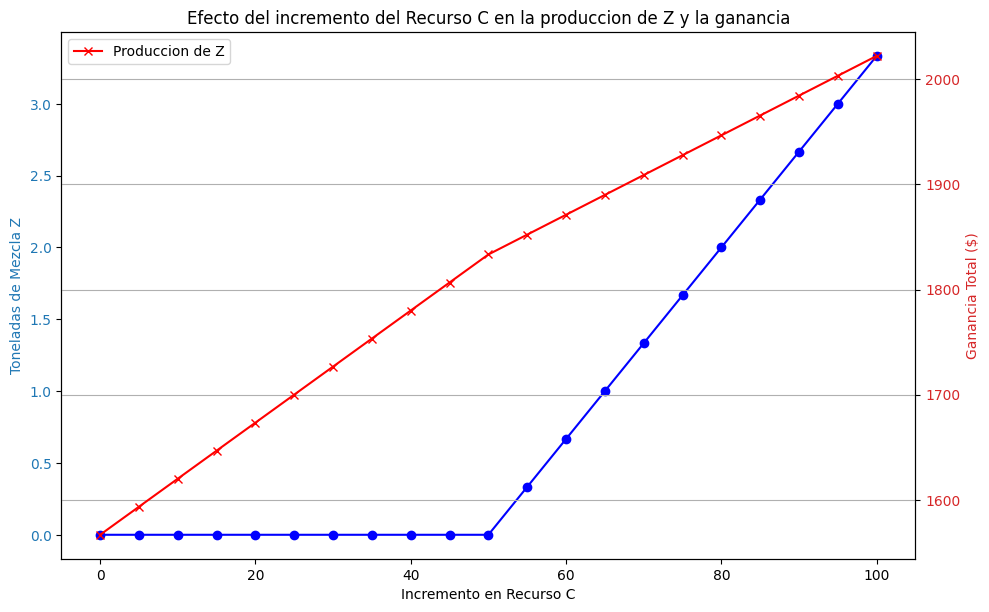

In [12]:
# Análisis paramétrico para el recurso C

# Hacemos incrementos en el recurso C y analizamos el impacto en la solucion
increments = range(0, 105, 5)  # Incrementos de 5 unidades hasta 100 adicionales

# Almacenamos los resultados en una lista vacía
results = []

# Iteramos sobre los incrementos para la creacion de nuevos modelos
for inc in increments:
    
    # Creamos un nuevo modelo con recurso C incrementado
    prob_inc = pl.LpProblem(f"Recurso_C_Incrementado_{inc}", pl.LpMaximize)
    
    # Definimos las variables
    x_inc = pl.LpVariable("Mezcla_X", lowBound=0)
    y_inc = pl.LpVariable("Mezcla_Y", lowBound=0)
    z_inc = pl.LpVariable("Mezcla_Z", lowBound=0)
    
    # Funcion objetivo
    prob_inc += 60*x_inc + 70*y_inc + 100*z_inc, "Ganancia Total"
    
    # Restricciones con C incrementado
    prob_inc += 20*x_inc + 10*y_inc + 10*z_inc <= 300, "Restriccion Reactivo A"
    prob_inc += 10*x_inc + 20*y_inc + 10*z_inc <= 500, "Restriccion Reactivo B"
    prob_inc += 5*x_inc + 10*y_inc + 20*z_inc <= 200 + inc, f"Restriccion Reactivo C + {inc}"
    
    # Resolvemos
    prob_inc.solve()
    
    # Guardamos los resultados en la lista vacia que creamos al principio
    results.append({
        "Incremento C": inc,
        "Mezcla X": x_inc.value(),
        "Mezcla Y": y_inc.value(),
        "Mezcla Z": z_inc.value(),
        "Ganancia": pl.value(prob_inc.objective)
    })

# Convertimos resultados a DataFrame para mejor visualizacion
df_results = pd.DataFrame(results)
df_results

# Graficamos como cambia la produccion de Z y la ganancia
fig, ax1 = plt.subplots(figsize=(10, 6))

# Declaramos los cuadrantes del gráfico de subplots (primero el eje y)
ax1.set_xlabel('Incremento en Recurso C')
ax1.set_ylabel('Toneladas de Mezcla Z', color='tab:blue')
ax1.plot(df_results['Incremento C'], df_results['Mezcla Z'], 'b-', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Creamos el segundo eje y
ax2 = ax1.twinx()
ax2.set_ylabel('Ganancia Total ($)', color='tab:red')
ax2.plot(df_results['Incremento C'], df_results['Ganancia'], 'r-', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Ajustamos el layout y mostramos el gráfico con su titulo
fig.tight_layout()
plt.title('Efecto del incremento del Recurso C en la produccion de Z y la ganancia')
plt.grid(True)
plt.legend(['Produccion de Z', 'Ganancia Total'], loc='upper left')
plt.show()

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

> # **Conclusiones**

Basado en el analisis de sensibilidad realizado, puedo concluir lo siguiente:

> ### **1️⃣ Recurso critico:**

El recurso mas critico es claramente el `Reactivo C` con un precio sombra de `5.33`. Esto significa que por cada unidad adicional de este reactivo que pudieramos obtener, nuestra ganancia `aumentaria en $5.33`. Los otros recursos tienen un impacto mucho menor: el `Reactivo A tiene un precio sombra de 1.67`, mientras que el `Reactivo B tiene un valor practicamente de cero`, lo que indica que no estamos utilizando todo este recurso o no es una restriccion limitante en nuestro problema.

> ### **2️⃣ Impacto del cambio de precio en la Mezcla Y:**

Cuando el precio de la mezcla Y baja de $70 a $60, observamos cambios significativos en la solucion optima:

- La produccion de la mezcla `Y se reduce completamente a 0 toneladas`
- Nuestra produccion se enfoca en las mezclas `X` (11.43 toneladas) y `Z` (7.14 toneladas)
- La ganancia total `disminuye en $166.67`, pasando a ser $1400.00
- Esto demuestra que la reduccion del precio hace que la `mezcla Y ya no sea rentable` en comparacion con las otras mezclas, por lo que el modelo decide no producirla.

> ### **3️⃣ Aumento del recurso C:**

Analizando el grafico parametrico, puedo concluir que:

- Se necesita un `aumento de aproximadamente 55 unidades` en el `recurso C` antes de que comencemos a ver un incremento en la produccion de la mezcla Z
- Antes de ese punto critico, agregar mas recurso C `no impacta la produccion de Z` (se mantiene en 0)
- Despues de las 55 unidades adicionales, `cada incremento del recurso C` permite `aumentar la produccion de Z` y la ganancia total de manera proporcional
- `La pendiente de crecimiento es constante`, lo que indica que cada unidad adicional del recurso C (despues del umbral) `genera un aumento consistente en la ganancia`

Honestamente me diverti mas haciendolo en Python que en Excel, me encanto este reto y creo que nunca va a dejar de encantarme. Siempre me divierto mas en Python ya que es lo que me gusta hacer y lo que me transporta a otro mundo. No es que Excel no sea bueno, pero me gusta mas mi Python. Pero bueno, gracias por ver este ejercicio y espero que pase feliz dia.

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background: linear-gradient(135deg, #28a745, #218838); color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 8px 16px rgba(0, 0, 0, 0.3); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center; border: 4px solid #1e7e34; position: relative;">
        <span style="text-shadow: 2px 2px 8px rgba(0, 0, 0, 0.5);">FIN</span>
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: rgba(255, 255, 255, 0.7); font-style: italic;">Jose Carlos Fernandez</p>
    </div>
</div>